Carga de datos

In [7]:
import pandas as pd

path = "./df_train.csv"
datos = pd.read_csv(path)

datos["Datetime"] = pd.to_datetime(datos["Datetime"])

subset = datos.loc[datos["Datetime"]<"2024-10-03"]

print(subset)

#print(datos.__class__)








        ID   Datetime       A         B      C        D         E        F  \
0        0 2004-10-01  328544       NaN  44255      NaN       NaN      NaN   
1        1 2004-10-02  311997       NaN  39398      NaN       NaN      NaN   
2        2 2004-10-03  293450       NaN  36689      NaN       NaN      NaN   
3        3 2004-10-04  343417       NaN  46237      NaN       NaN      NaN   
4        4 2004-10-05  346553       NaN  47283      NaN       NaN      NaN   
...    ...        ...     ...       ...    ...      ...       ...      ...   
4682  4682 2017-07-27  383108  347384.0  53720  89466.0  308598.0  44978.0   
4683  4683 2017-07-28  374735  310874.0  54228  87250.0  295989.0  44591.0   
4684  4684 2017-07-29  322949  267861.0  42683  72547.0  247948.0  35402.0   
4685  4685 2017-07-30  327174  267554.0  43957  73457.0  241869.0  37524.0   
4686  4686 2017-07-31  382389  319443.0  55049  86316.0  276587.0  43863.0   

            G         H  
0         NaN       NaN  
1         N

In [8]:
print(datos.head())

   ID   Datetime       A   B      C   D   E   F   G   H
0   0 2004-10-01  328544 NaN  44255 NaN NaN NaN NaN NaN
1   1 2004-10-02  311997 NaN  39398 NaN NaN NaN NaN NaN
2   2 2004-10-03  293450 NaN  36689 NaN NaN NaN NaN NaN
3   3 2004-10-04  343417 NaN  46237 NaN NaN NaN NaN NaN
4   4 2004-10-05  346553 NaN  47283 NaN NaN NaN NaN NaN


   ID   Datetime       A   B      C   D   E   F   G   H
0   0 2004-10-01  328544 NaN  44255 NaN NaN NaN NaN NaN
1   1 2004-10-02  311997 NaN  39398 NaN NaN NaN NaN NaN
2   2 2004-10-03  293450 NaN  36689 NaN NaN NaN NaN NaN
3   3 2004-10-04  343417 NaN  46237 NaN NaN NaN NaN NaN
4   4 2004-10-05  346553 NaN  47283 NaN NaN NaN NaN NaN


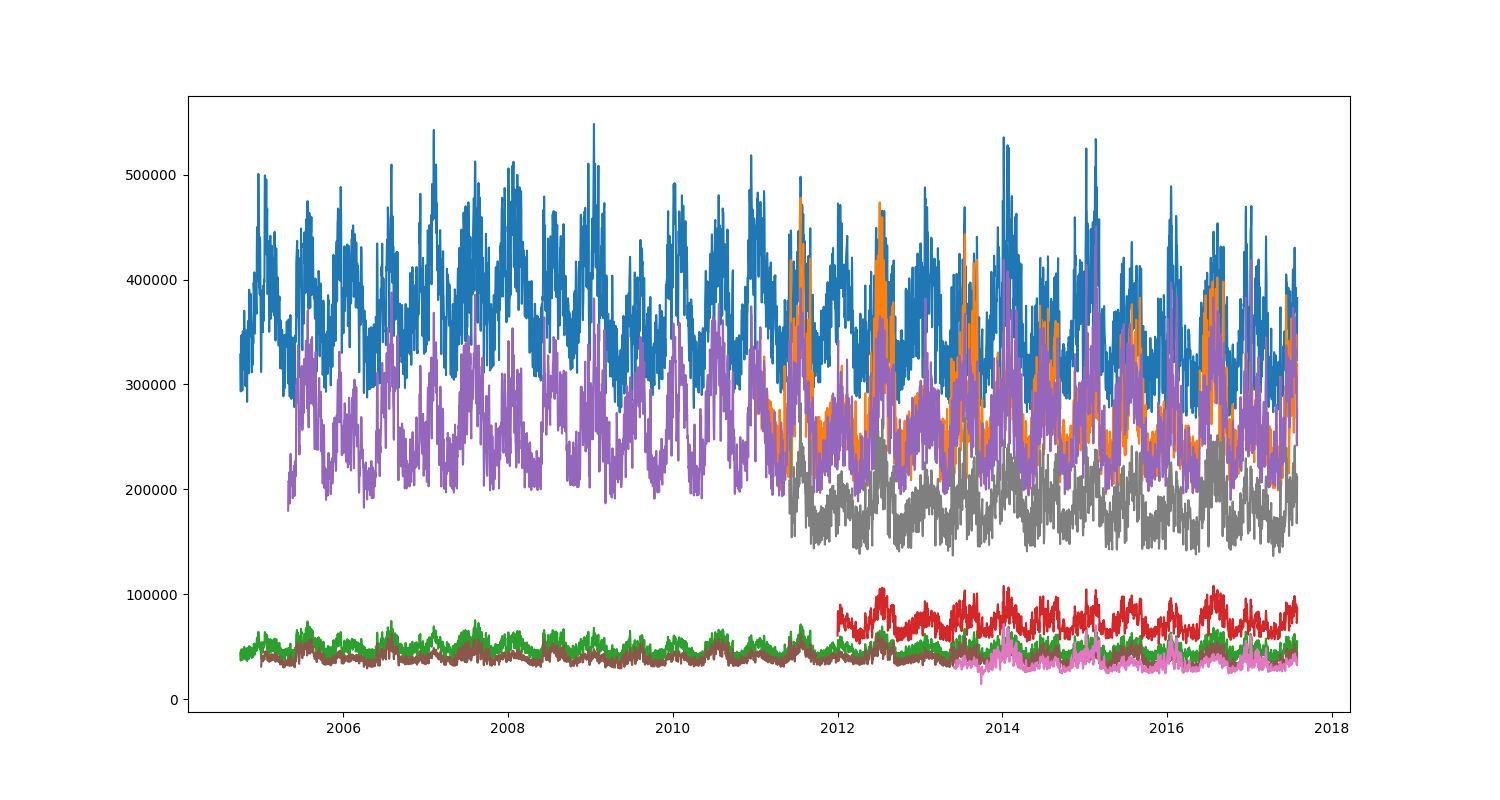

In [9]:
import matplotlib.pyplot as plt

%matplotlib widget

print(datos.head())

plt.figure(figsize=(15,8))
plt.plot(datos["Datetime"],datos["A"], label="A")
plt.plot(datos["Datetime"],datos["B"], label="B")
plt.plot(datos["Datetime"],datos["C"], label="C")
plt.plot(datos["Datetime"],datos["D"], label="D")
plt.plot(datos["Datetime"],datos["E"], label="E")
plt.plot(datos["Datetime"],datos["F"], label="F")
plt.plot(datos["Datetime"],datos["G"], label="G")
plt.plot(datos["Datetime"],datos["H"], label="H")

In [10]:


# Año y día del año
datos["year"] = datos["Datetime"].dt.year
datos["dayofyear"] = datos["Datetime"].dt.dayofyear

In [ ]:
datos

In [11]:
media_dia = (datos.groupby("dayofyear")["A"].mean())
print(media_dia.head())
print(media_dia.tail())

dayofyear
1    356948.230769
2    390648.769231
3    414865.000000
4    413335.461538
5    415951.846154
Name: A, dtype: float64
dayofyear
362    383042.692308
363    381178.461538
364    381186.461538
365    370267.230769
366    374813.750000
Name: A, dtype: float64


In [12]:
fechas = pd.date_range("2018-01-01", "2018-12-31",  freq="D" )

pronostico = pd.DataFrame({"Datetime": fechas })

pronostico["dayofyear"] = pronostico["Datetime"].dt.dayofyear
pronostico["A"] = pronostico["dayofyear"].map(media_dia)

In [17]:

# Entrenamiento
train = pd.read_csv("df_train.csv")
train["Datetime"] = pd.to_datetime(train["Datetime"])

# Sample submission
submission = pd.read_csv("sample_submission.csv")

columnas = ["A","B","C","D","E","F","G","H"]

# Mes y día
train["mes"] = train["Datetime"].dt.month
train["dia"] = train["Datetime"].dt.day

# Media histórica
media = ( train.groupby(["mes","dia"])[columnas].mean() )

In [18]:
fechas_test = pd.date_range(start="2017-08-01", periods=len(submission), freq="D")

pred = pd.DataFrame({ "mes": fechas_test.month, "dia": fechas_test.day })

pred = pred.merge( media, on=["mes","dia"], how="left" )

In [19]:
submission[columnas] = pred[columnas]

submission.to_csv("submission.csv", index=False)

In [20]:
def dia_relativo_agosto(fecha):
    anio = fecha.year

    # 1 de agosto de ese año
    inicio = pd.Timestamp(anio, 8, 1)

    # Primer lunes desde el 1 de agosto
    primer_lunes = inicio + pd.Timedelta(days=(7 - inicio.weekday()) % 7)

    return (fecha.normalize() - primer_lunes).days + 1

In [21]:
train["dia_relativo"] = train["Datetime"].apply(dia_relativo_agosto)

media = (
    train.groupby("dia_relativo")[columnas]
         .mean()
)

In [22]:
fechas_test = pd.date_range("2017-08-01", periods=365, freq="D")

pred = pd.DataFrame({
    "Datetime": fechas_test
})

pred["dia_relativo"] = pred["Datetime"].apply(dia_relativo_agosto)

pred = pred.merge(media, on="dia_relativo", how="left")

In [23]:
# Fechas del período a predecir
fechas_test = pd.date_range("2017-08-01", periods=365, freq="D")

pred = pd.DataFrame({"Datetime": fechas_test})

pred["dia_relativo"] = pred["Datetime"].apply(dia_relativo_agosto)

pred = pred.merge(media, on="dia_relativo", how="left")

# Agregar ID
pred.insert(0, "ID", range(len(pred)))

# Quedarse solo con las columnas requeridas
submission = pred[["ID", "A", "B", "C", "D", "E", "F", "G", "H"]]

# Guardar
submission.to_csv("submission.csv", index=False)